In [1]:
# the libraries
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib.colors as mcolors




from pylab import rcParams
rcParams['axes.labelweight'] = 'bold'
rcParams['axes.labelsize'] = 'x-large'
rcParams['axes.titlesize'] = 'xx-large'
rcParams['axes.titleweight'] = 'bold'




In [2]:
#functions



def build_weights(data, datadata, minvalue = -999, latlim = 90.):
    weights = datadata.isel(time = 0) > minvalue
    weights = weights *np.cos( np.deg2rad(data.lat))
    weights = weights*(abs(data.lat)<latlim)
    return weights

def anomaly(glbmean, weights, normalise = False, detrend = False):

    #detrend if desired
    if detrend:
        glbmean = glbmean.groupby('time.month').apply(detrend_monthly)

    
    databymth = glbmean.groupby("time.month")
    mthclim = databymth.mean("time")       # detrended climatological months (seasonal cycle)
    
    dataanom = databymth - mthclim          # detrended interannual annomaly
    if normalise:
        dataanom = dataanom/dataanom.std()
    dataanom = dataanom.rename('anom')   # change variable name
    return dataanom

def anomaly_daily(glbmean, weights, normalise = False, detrend = False):

    #detrend if desired
    if detrend:
        glbmean = glbmean.groupby('time.dayofyear').apply(detrend_monthly)

    
    databymth = glbmean.groupby("time.dayofyear")
    mthclim = databymth.mean("time")       # detrended climatological months (seasonal cycle)
    
    dataanom = databymth - mthclim          # detrended interannual annomaly
    if normalise:
        dataanom = dataanom/dataanom.std()
    dataanom = dataanom.rename('anom')   # change variable name
    return dataanom


def detrend_monthly(group):
    ns_century = 1.e9*3600.*24.*365.*100.
    linfit = group.polyfit('time', 1)
    slope = linfit.polyfit_coefficients.isel(degree=0) * ns_century

    trend = xr.polyval(coord=group.time, coeffs=linfit.polyfit_coefficients)
    detrended_group = group - trend.values + group.mean(dim='time')

    return detrended_group


def global_mean(data, datadata, weights):
    datadata_weighted = datadata.weighted(weights)
    weighted_mean = datadata_weighted.mean(('lat', 'lon'))
    return weighted_mean

def lat_bands_gt(data, datadata, minlat,maxlat, detrend = False):
    #select region
    data = data.sel(lat = slice(maxlat,minlat))
    datadata = datadata.sel(lat = slice(maxlat,minlat))
    #calculate anomaly
    data_weights = build_weights(data, datadata)
    data_glbmean = global_mean(data, datadata, data_weights)
    data_glbanom = anomaly(data_glbmean, data_weights, detrend = detrend)
    return data_glbanom


def decode_time(filepath):
    ds = xr.open_dataset(filepath, decode_times=False)
    units, reference_date = ds.time.attrs['units'].split('since')
    ds['time'] = pd.date_range(start=reference_date, periods=ds.sizes['time'], freq='MS')
    return ds

def encode_time(ds, reference_time = '1958-01-01', period = 'months'):
    ds.time.encoding['calendar'] = '360_day'
    ds.time.encoding['units'] = '{} since {}'.format(period, reference_time)
    return ds




def detrend_monthly(group):
    ns_century = 1.e9*3600.*24.*365.*100.
    linfit = group.polyfit('time', 1)
    slope = linfit.polyfit_coefficients.isel(degree=0) * ns_century

    trend = xr.polyval(coord=group.time, coeffs=linfit.polyfit_coefficients)
    detrended_group = group - trend.values + group.mean(dim='time')

    return detrended_group




In [ ]:
#load dataset
fp = '/data/jmex/ERA5/daily/era5_tp_daily_130-150E_-20-20N.nc'
tp = xr.open_dataset(fp)

#select rev. time only
tp = tp.sel(time = slice('1958-01-01', '2023-12-31'))

In [3]:
#compute the mean
tp_weights = build_weights(tp, tp.tp)
tp_glbmean = global_mean(tp, tp.tp, tp_weights)



#compute the anomaly
tp_glbanom = anomaly_daily(tp_glbmean, tp_weights, detrend = False)

tp['glb_mean'] = tp_glbmean.rolling(time = 90).mean('time', center = True)
tp['glb_anom'] = tp_glbanom.rolling(time = 90).mean('time', center = True)

In [6]:
# load nino
fp = '/data/jmex/output/drivers/indices/nino.nc'
nino = decode_time(fp)
ninoOND = nino.where(nino.time.dt.month.isin([10,11,12])).groupby('time.year').mean()
ninoJAS = nino.where(nino.time.dt.month.isin([7,8,9])).groupby('time.year').mean()
ninoJFM = nino.where(nino.time.dt.month.isin([1,2,3])).groupby('time.year').mean()

# SST_dashed 

In [15]:
fp = '/data/jmex/output/circulation/sst_dashed.nc'
sst = decode_time(fp)

In [16]:
#select western part
sst_west = sst.sel(lat = slice(20,-20), lon = slice(130,150), time = slice('1958-01-01', '2023-12-31') )

#compute weighted average
sst_weights = np.cos(np.deg2rad(sst_west.lat))
sst_west_mean = global_mean(sst_west, sst_west.sst_dashed, sst_weights).rolling(time = 3, center = True).mean()

In [17]:
#compute the anomaly
sst_west_anom = anomaly(sst_west_mean, sst_weights, detrend = False)

sst_west['box_mean'] = sst_west_mean
sst_west['anom'] = sst_west_anom

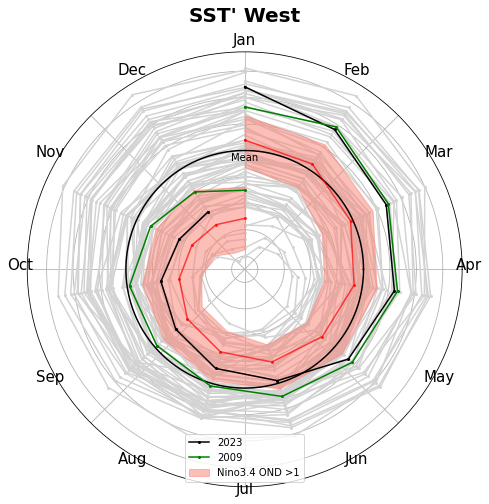

In [18]:
months=["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

full_circle_thetas=np.linspace(0,2*np.pi,1000)
blue_one_radii=[0.0+1]*1000



# Extract years and months
years = np.unique(sst_west.time.dt.year)

# Plotting
fig = plt.figure(figsize=(8,8))
ax = plt.subplot(111, projection='polar')#visuals
ax.axes.get_yaxis().set_ticklabels([])
ax.axes.get_xaxis().set_ticklabels([])

ax.plot(full_circle_thetas, blue_one_radii, c='k', zorder= 10)
ax.text(np.pi/2, .90, "Mean", color="k", ha='center', zorder = 10)

#add months ring
months_angles= -np.linspace(0,2*np.pi,13)+np.pi/2
for i,month in enumerate(months):
    ax.text(months_angles[i],2,month,color="k",fontsize=15,ha="center")


for i, year in enumerate(years):
    temp = sst_west.where((sst_west.time.dt.year== year), drop = True).anom.values

    # Calculate the angle for the current month
    angle = -np.linspace(0, 2*np.pi, len(temp))+np.pi/2

    # Calculate radius for temperature
    radius = temp +1
    ax.plot(angle, radius, marker='o', markersize=2, c='lightgrey')
    

add_nino = True
add_nino_all = False
add_nino2 = False

add_nina = False
    
#year == 2023:

temp = sst_west.sel(time = '2023').anom.values
angle = -np.linspace(0,2*np.pi, len(temp))+np.pi/2
radius = temp+1
ax.plot(angle, radius, marker = 'o', markersize = 2, label = '2023', color = 'k', zorder = 20)

#year == 2009:

temp = sst_west.sel(time = '2009').anom.values
angle = -np.linspace(0,2*np.pi, len(temp))+np.pi/2
radius = temp+1
ax.plot(angle, radius, marker = 'o', markersize = 2, label = '2009', color = 'g', zorder = 20)


if add_nino:
    #nino
    nino_W = sst_west.sel(time = sst_west.time.dt.year.isin(ninoOND.where(ninoOND.nino34>1., drop = True).year[:-1]))
    temp_m = nino_W.groupby('time.month').mean().anom.values
    temp_10 = nino_W.anom.groupby('time.month').quantile(.10)
    temp_90 = nino_W.anom.groupby('time.month').quantile(0.9)

    angle = -np.linspace(0,2*np.pi, len(temp_m))+np.pi/2
    radius_m = temp_m+1
    ax.plot(angle, radius_m, marker = 'o', markersize = 2, color = 'red', zorder = 10, alpha = 0.7)
    ax.fill_between(angle, temp_10+1, temp_90+1, color = 'salmon', label = 'Nino3.4 OND >1', zorder= 10, alpha = 0.5)


if add_nino_all:
    #nino
    nino_W = sst_west.sel(time = sst_west.time.dt.year.isin(ninoOND.where(ninoOND.nino34>1., drop = True).year[:-1]))
    temp_m = nino_W.groupby('time.month').mean().anom.values

    angle = -np.linspace(0,2*np.pi, len(temp_m))+np.pi/2
    radius_m = temp_m+1
    #ax.plot(angle, radius_m, marker = 'o', markersize = 2, color = 'red', zorder = 10, alpha = 0.7)

    for year in np.unique(nino_W.time.dt.year):
        temp = sst_west.where((sst_west.time.dt.year==year), drop = True).anom.values
        angle = -np.linspace(0, 2*np.pi, len(temp))+np.pi/2
        radius = temp+1
        ax.plot(angle, radius, marker = 'o', markersize = 2, label = year)




if add_nina:
    #nina
    nina_W = sst_west.sel(time = sst_west.time.dt.year.isin(ninoOND.where(ninoOND.nino34<-1, drop = True).year+1))
    temp_m = nina_W.groupby('time.month').mean().anom.values
    temp_10 = nina_W.anom.groupby('time.month').quantile(.10)
    temp_90 = nina_W.anom.groupby('time.month').quantile(.90)


    angle = -np.linspace(0,2*np.pi, len(temp_m))+np.pi/2
    radius_m = temp_m+1
    ax.plot(angle, radius_m, marker = 'o', markersize = 2, color = 'blue', zorder = 10)
    ax.fill_between(angle, temp_10+1, temp_90+1, color = 'lightblue', alpha = 0.7, label = 'Nino3.4 OND-1<-1',zorder = 10)
 
 
# Set title and show the plot
ax.set_title('SST\' West', color='k', fontdict={'fontsize': 20}, pad  = 30)
ax.legend(loc = 'lower center')



# SST 


In [23]:
fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
sst = decode_time(fp)

#select western part
sst_west = sst.sel(lat = slice(20,-20), lon = slice(130,150))

#compute weighted average
sst_weights = np.cos(np.deg2rad(sst_west.lat))
sst_west_mean = global_mean(sst_west, sst_west.sst, sst_weights).rolling(time = 3, center = True).mean()


In [24]:
#compute the anomaly
sst_west_anom = anomaly(sst_west_mean, sst_weights, detrend = True)

In [25]:
sst_west['box_mean'] = sst_west_mean
sst_west['anom'] = sst_west_anom

Text(0.5, 1.0, 'SST yearly')

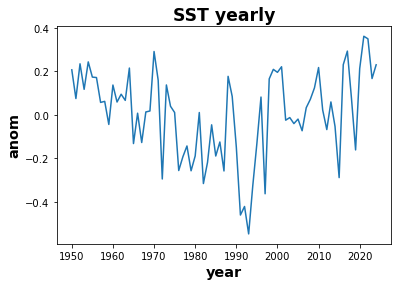

In [26]:
sst_west.anom.groupby('time.year').mean().plot()
plt.title('SST yearly')

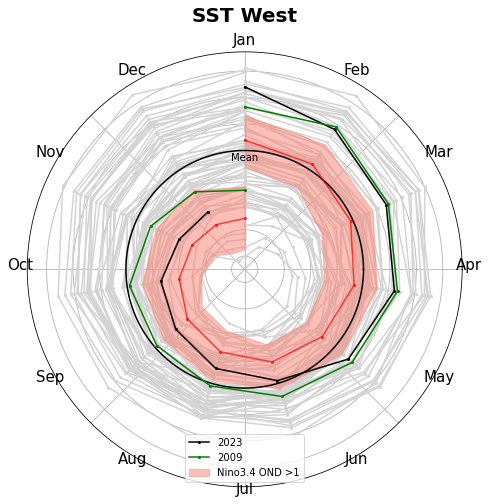

In [25]:
months=["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

full_circle_thetas=np.linspace(0,2*np.pi,1000)
blue_one_radii=[0.0+1]*1000



# Extract years and months
years = np.unique(sst_west.time.dt.year)

# Plotting
fig = plt.figure(figsize=(8,8))
ax = plt.subplot(111, projection='polar')#visuals
ax.axes.get_yaxis().set_ticklabels([])
ax.axes.get_xaxis().set_ticklabels([])

ax.plot(full_circle_thetas, blue_one_radii, c='k', zorder= 10)
ax.text(np.pi/2, .90, "Mean", color="k", ha='center', zorder = 10)

#add months ring
months_angles= -np.linspace(0,2*np.pi,13)+np.pi/2
for i,month in enumerate(months):
    ax.text(months_angles[i],2,month,color="k",fontsize=15,ha="center")


for i, year in enumerate(years):
    temp = sst_west.where((sst_west.time.dt.year== year), drop = True).anom.values

    # Calculate the angle for the current month
    angle = -np.linspace(0, 2*np.pi, len(temp))+np.pi/2

    # Calculate radius for temperature
    radius = temp +1
    ax.plot(angle, radius, marker='o', markersize=2, c='lightgrey')
    

add_nino = True
add_nino_all = False
add_nino2 = False

add_nina = False
    
#year == 2023:

temp = sst_west.sel(time = '2023').anom.values
angle = -np.linspace(0,2*np.pi, len(temp))+np.pi/2
radius = temp+1
ax.plot(angle, radius, marker = 'o', markersize = 2, label = '2023', color = 'k', zorder = 20)

#year == 2023:

temp = sst_west.sel(time = '2009').anom.values
angle = -np.linspace(0,2*np.pi, len(temp))+np.pi/2
radius = temp+1
ax.plot(angle, radius, marker = 'o', markersize = 2, label = '2009', color = 'g', zorder = 20)

if add_nino:
    #nino
    nino_W = sst_west.sel(time = sst_west.time.dt.year.isin(ninoOND.where(ninoOND.nino34>1, drop = True).year[:-1]))
    temp_m = nino_W.groupby('time.month').mean().anom.values
    temp_10 = nino_W.anom.groupby('time.month').quantile(.10)
    temp_90 = nino_W.anom.groupby('time.month').quantile(0.9)

    angle = -np.linspace(0,2*np.pi, len(temp_m))+np.pi/2
    radius_m = temp_m+1
    ax.plot(angle, radius_m, marker = 'o', markersize = 2, color = 'red', zorder = 10, alpha = 0.7)
    ax.fill_between(angle, temp_10+1, temp_90+1, color = 'salmon', label = 'Nino3.4 OND >1', zorder= 10, alpha = 0.5)


if add_nino_all:
    #nino
    nino_W = sst_west.sel(time = sst_west.time.dt.year.isin(ninoOND.where(ninoOND.nino34>1, drop = True).year[:-1]))
    temp_m = nino_W.groupby('time.month').mean().anom.values

    angle = -np.linspace(0,2*np.pi, len(temp_m))+np.pi/2
    radius_m = temp_m+1
    #ax.plot(angle, radius_m, marker = 'o', markersize = 2, color = 'red', zorder = 10, alpha = 0.7)

    for year in np.unique(nino_W.time.dt.year):
        temp = sst_west.where((sst_west.time.dt.year==year), drop = True).anom.values
        angle = -np.linspace(0, 2*np.pi, len(temp))+np.pi/2
        radius = temp+1
        ax.plot(angle, radius, marker = 'o', markersize = 2, c = 'salmon')




if add_nina:
    #nina
    nina_W = sst_west.sel(time = sst_west.time.dt.year.isin(ninoOND.where(ninoOND.nino34<-1, drop = True).year+1))
    temp_m = nina_W.groupby('time.month').mean().anom.values
    temp_10 = nina_W.anom.groupby('time.month').quantile(.10)
    temp_90 = nina_W.anom.groupby('time.month').quantile(.90)


    angle = -np.linspace(0,2*np.pi, len(temp_m))+np.pi/2
    radius_m = temp_m+1
    ax.plot(angle, radius_m, marker = 'o', markersize = 2, color = 'blue', zorder = 10)
    ax.fill_between(angle, temp_10+1, temp_90+1, color = 'lightblue', alpha = 0.7, label = 'Nino3.4 OND-1<-1',zorder = 10)
 
 
# Set title and show the plot
ax.set_title(r'SST West', color='k', fontdict={'fontsize': 20}, pad  = 30)
ax.legend(loc = 'lower center')

#plt.savefig('/data/jmex/output/figures/sandrine/walker_slp_nino.png')

In [108]:
np.unique(nino_W.time.dt.year)

array([1965, 1972, 1982, 1987, 1997, 2002, 2009, 2015])

# Walker Cell

In [37]:
## defined as Pressure difference

In [18]:
fp = '/data/jmex/output/circulation/W_msl.nc'
W_msl = xr.open_dataset(fp)

#take rolling average over 30days
W_msl = W_msl.rolling(time = 30, center = True).mean()



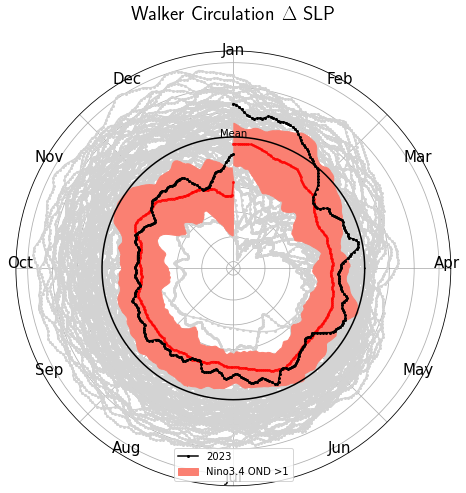

In [19]:
months=["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

full_circle_thetas=np.linspace(0,2*np.pi,1000)
blue_one_radii=[0.0+1]*1000



# Extract years and months
years = np.unique(W_msl.time.dt.year)

# Plotting
fig = plt.figure(figsize=(8,8))
ax = plt.subplot(111, projection='polar')#visuals
ax.axes.get_yaxis().set_ticklabels([])
ax.axes.get_xaxis().set_ticklabels([])

ax.plot(full_circle_thetas, blue_one_radii, c='k', zorder= 10)
ax.text(np.pi/2, 0.90, "Mean", color="k", ha='center', zorder = 10)

#add months ring
months_angles= -np.linspace(0,2*np.pi,13)+np.pi/2
for i,month in enumerate(months):
    ax.text(months_angles[i],330,month,color="k",fontsize=15,ha="center")


for i, year in enumerate(years):
    temp = W_msl.where((W_msl.time.dt.year== year), drop = True).anom.values

    # Calculate the angle for the current month
    angle = -np.linspace(0, 2*np.pi, len(temp))+np.pi/2

    # Calculate radius for temperature
    radius = temp +1
    ax.plot(angle, radius, marker='o', markersize=2, c='lightgrey')
    

add_nino = True
add_nino2 = False

add_nina = False
    
#year == 2023:

temp = W_msl.sel(time = '2023').anom.values
angle = -np.linspace(0,2*np.pi, len(temp))+np.pi/2
radius = temp+1
ax.plot(angle, radius, marker = 'o', markersize = 2, label = '2023', color = 'k', zorder = 20)

if add_nino:
    #nino
    nino_W = W_msl.sel(time = W_msl.time.dt.year.isin(ninoOND.where(ninoOND.nino34>1, drop = True).year[:-1]))
    temp_m = nino_W.groupby('time.dayofyear').mean().anom.values
    temp_10 = nino_W.anom.groupby('time.dayofyear').quantile(.10)
    temp_90 = nino_W.anom.groupby('time.dayofyear').quantile(0.9)

    angle = -np.linspace(0,2*np.pi, len(temp_m))+np.pi/2
    radius_m = temp_m+1
    ax.plot(angle, radius_m, marker = 'o', markersize = 2, color = 'red', zorder = 10, alpha = 0.7)
    ax.fill_between(angle, temp_10+1, temp_90+1, color = 'salmon', label = 'Nino3.4 OND >1', zorder= 10)



if add_nino2:
    #nino
    nino_W = W.sel(time = W.time.dt.year.isin(ninoOND.where(ninoOND.nino34>1, drop = True).year[:-1]))
    nino_W1 = nino_W.sel(time = slice('1958', '1990'))
    nino_W2 = nino_W.sel(time = slice('1991', '2023'))
    
    temp_m1 = nino_W1.groupby('time.dayofyear').mean().W.values
    temp_m2 = nino_W2.groupby('time.dayofyear').mean().W.values
    
    temp_101 = nino_W1.W.groupby('time.dayofyear').quantile(.10)
    temp_901 = nino_W1.W.groupby('time.dayofyear').quantile(.90)

     
    temp_102 = nino_W2.W.groupby('time.dayofyear').quantile(.10)
    temp_902 = nino_W2.W.groupby('time.dayofyear').quantile(.90)

    angle = -np.linspace(0,2*np.pi, len(temp_m1))+np.pi/2
    radius_m = temp_m1+1
    ax.plot(angle, radius_m, marker = 'o', markersize = 2, color = 'lightgrey')
    ax.fill_between(angle, temp_101+1, temp_901+1, color = 'grey', label = 'Nino3.4 OND >1 1958-1990', alpha = 0.7)
    
    
    angle = -np.linspace(0,2*np.pi, len(temp_m2))+np.pi/2
    radius_m = temp_m2+1
    ax.plot(angle, radius_m, marker = 'o', markersize = 2, color = 'red')
    ax.fill_between(angle, temp_102+1, temp_902+1, color = 'salmon', label = 'Nino3.4 OND >1 1991-2022', alpha = 0.3)
    



if add_nina:
    #nina
    nina_W = W_msl.sel(time = W_msl.time.dt.year.isin(ninoOND.where(ninoOND.nino34<-1, drop = True).year+1))
    temp_m = nina_W.groupby('time.dayofyear').mean().anom.values
    temp_10 = nina_W.anom.groupby('time.dayofyear').quantile(.10)
    temp_90 = nina_W.anom.groupby('time.dayofyear').quantile(.90)


    angle = -np.linspace(0,2*np.pi, len(temp_m))+np.pi/2
    radius_m = temp_m+1
    ax.plot(angle, radius_m, marker = 'o', markersize = 2, color = 'blue', zorder = 10)
    ax.fill_between(angle, temp_10+1, temp_90+1, color = 'lightblue', alpha = 0.7, label = 'Nino3.4 OND-1<-1',zorder = 10)
 
 
# Set title and show the plot
ax.set_title(r'Walker Circulation $\Delta$ SLP', color='k', fontdict={'fontsize': 20}, pad  = 30, usetex = True)
ax.legend(loc = 'lower center')

#plt.savefig('/data/jmex/output/figures/sandrine/walker_slp_nino.png')


## Defined as w500 branch differences
walker circulation index locations of branches: 
wwest = w.sel(lat = slice(15,-15), lon = slice(110, 150)).where(w.w <0)
weast = w.sel(lat = slice(15,-15), lon = slice(220, 280)).where(w.w >0)

In [5]:
fp = '/data/jmex/output/circulation/W_w500.nc'
W_w500 = xr.open_dataset(fp)

#take rolling average over 3 months
W_w500 = W_w500.rolling(time = 3, center = True).mean()


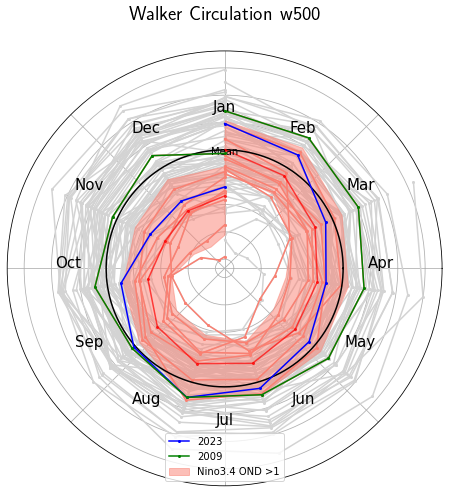

In [14]:
months=["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

full_circle_thetas=np.linspace(0,2*np.pi,1000)
blue_one_radii=[0.0+1]*1000



# Extract years and months
years = np.unique(W_w500.time.dt.year)

# Plotting
fig = plt.figure(figsize=(8,8))
ax = plt.subplot(111, projection='polar')#visuals
ax.axes.get_yaxis().set_ticklabels([])
ax.axes.get_xaxis().set_ticklabels([])

ax.plot(full_circle_thetas, blue_one_radii, c='k', zorder= 10)
ax.text(np.pi/2, 0.90, "Mean", color="k", ha='center', zorder = 10)

#add months ring
months_angles= -np.linspace(0,2*np.pi,13)+np.pi/2
for i,month in enumerate(months):
    ax.text(months_angles[i],1.7,month,color="k",fontsize=15,ha="center")


for i, year in enumerate(years):
    temp = W_w500.where((W_w500.time.dt.year== year), drop = True).w2w.values

    # Calculate the angle for the current month
    angle = -np.linspace(0, 2*np.pi, len(temp))+np.pi/2

    # Calculate radius for temperature
    radius = temp +1
    ax.plot(angle, radius, marker='o', markersize=2, c='lightgrey')
    

add_nino = True
add_nino_all = True
add_nino2 = False

add_nina = False
    
#year == 2023:

temp = W_w500.sel(time = '2023').w2w.values
angle = -np.linspace(0,2*np.pi, len(temp))+np.pi/2
radius = temp+1
ax.plot(angle, radius, marker = 'o', markersize = 2, label = '2023', color = 'blue', zorder = 20)

#year == 2009:

temp = W_w500.sel(time = '2009').w2w.values
angle = -np.linspace(0,2*np.pi, len(temp))+np.pi/2
radius = temp+1
ax.plot(angle, radius, marker = 'o', markersize = 2, label = '2009', color = 'g', zorder = 20)



if add_nino:
    #nino
    nino_W = W_w500.sel(time = W_w500.time.dt.year.isin(ninoOND.where(ninoOND.nino34>1, drop = True).year[:-1]))
    temp_m = nino_W.groupby('time.month').mean().w2w.values
    temp_10 = nino_W.w2w.groupby('time.month').quantile(.10)
    temp_90 = nino_W.w2w.groupby('time.month').quantile(0.9)

    angle = -np.linspace(0,2*np.pi, len(temp_m))+np.pi/2
    radius_m = temp_m+1
    ax.plot(angle, radius_m, marker = 'o', markersize = 2, color = 'red', zorder = 10, alpha = 0.7)
    ax.fill_between(angle, temp_10+1, temp_90+1, color = 'salmon', label = 'Nino3.4 OND >1', zorder = 10, alpha = 0.5)



if add_nino2:
    #nino
    nino_W = W.sel(time = W.time.dt.year.isin(ninoOND.where(ninoOND.nino34>1, drop = True).year[:-1]))
    nino_W1 = nino_W.sel(time = slice('1958', '1990'))
    nino_W2 = nino_W.sel(time = slice('1991', '2023'))
    
    temp_m1 = nino_W1.groupby('time.month').mean().w2w.values
    temp_m2 = nino_W2.groupby('time.month').mean().w2w.values
    
    temp_101 = nino_W1.w2w.groupby('time.month').quantile(.10)
    temp_901 = nino_W1.w2w.groupby('time.month').quantile(.90)

     
    temp_102 = nino_W2.w2w.groupby('time.month').quantile(.10)
    temp_902 = nino_W2.w2w.groupby('time.month').quantile(.90)

    angle = -np.linspace(0,2*np.pi, len(temp_m1))+np.pi/2
    radius_m = temp_m1+1
    ax.plot(angle, radius_m, marker = 'o', markersize = 2, color = 'lightgrey')
    ax.fill_between(angle, temp_101+1, temp_901+1, color = 'grey', label = 'Nino3.4 OND >1 1958-1990', alpha = 0.7)
    
    
    angle = -np.linspace(0,2*np.pi, len(temp_m2))+np.pi/2
    radius_m = temp_m2+1
    ax.plot(angle, radius_m, marker = 'o', markersize = 2, color = 'red')
    ax.fill_between(angle, temp_102+1, temp_902+1, color = 'salmon', label = 'Nino3.4 OND >1 1991-2022', alpha = 0.3)
    

if add_nino_all:
    #nino
    nino_W = W_w500.sel(time = W_w500.time.dt.year.isin(ninoOND.where(ninoOND.nino34>1, drop = True).year[:-1]))
    temp_m = nino_W.groupby('time.month').mean().w2w.values

    angle = -np.linspace(0,2*np.pi, len(temp_m))+np.pi/2
    radius_m = temp_m+1
    #ax.plot(angle, radius_m, marker = 'o', markersize = 2, color = 'red', zorder = 10, alpha = 0.7)

    for year in np.unique(nino_W.time.dt.year):
        temp = W_w500.where((W_w500.time.dt.year==year), drop = True).w2w.values
        angle = -np.linspace(0, 2*np.pi, len(temp))+np.pi/2
        radius = temp+1
        ax.plot(angle, radius, marker = 'o', markersize = 2, c = 'salmon')



if add_nina:
    #nina
    nina_W = W_w500.sel(time = W_w500.time.dt.year.isin(ninoOND.where(ninoOND.nino34<-1, drop = True).year+1))
    temp_m = nina_W.groupby('time.month').mean().w2w.values
    temp_10 = nina_W.w2w.groupby('time.month').quantile(.10)
    temp_90 = nina_W.w2w.groupby('time.month').quantile(.90)


    angle = -np.linspace(0,2*np.pi, len(temp_m))+np.pi/2
    radius_m = temp_m+1
    ax.plot(angle, radius_m, marker = 'o', markersize = 2, color = 'blue', zorder = 10)
    ax.fill_between(angle, temp_10+1, temp_90+1, color = 'lightblue', alpha = 0.7, label = 'Nino3.4 OND-1<-1',zorder = 10)
 
 

# Set title and show the plot
ax.set_title(r'Walker Circulation w500', color='k', fontdict={'fontsize': 20}, pad  = 30, usetex = True)
ax.legend(loc = 'lower center')

#plt.savefig('/data/jmex/output/figures/sandrine/walker_slp_nino.png')

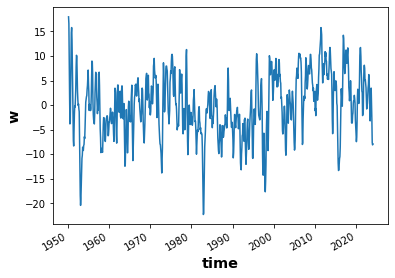

In [43]:
W_anom.w.plot()

Text(0, 0.5, 'W_msl Difference East-West')

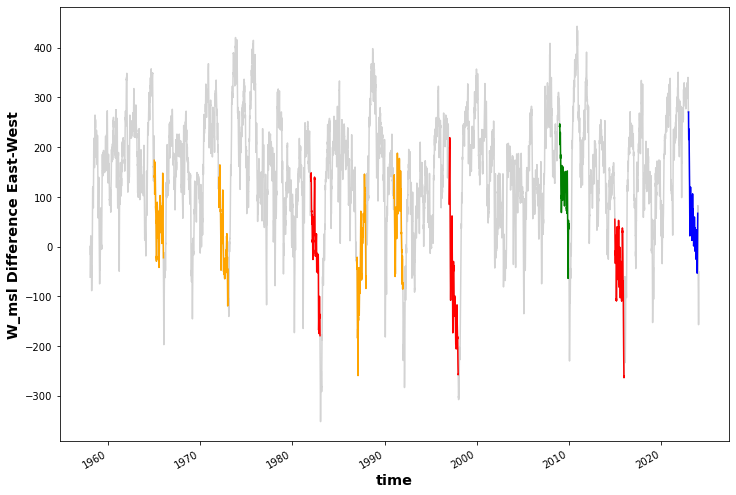

In [21]:

vstrong_ninos = [1982, 1997, 2015]
strong_ninos = [1965, 1972,1987, 1991]


W_slp = W_msl
fig, ax = plt.subplots(1,1, figsize = (12,8))


W_slp.msl.plot(color = 'lightgrey')

W_sel = W_slp.sel(time = '2023')
sns.lineplot(data = W_sel, x = W_sel.time, y = W_sel.msl,  color = 'b')


for v in vstrong_ninos:
    W_sel = W_slp.sel(time = str(v))
    sns.lineplot(data = W_sel, x = W_sel.time, y = W_sel.msl,  color = 'r')
    

for s in strong_ninos:
    W_sel = W_slp.sel(time = str(s))
    sns.lineplot(data = W_sel, x = W_sel.time, y = W_sel.msl, color = 'orange')
    

W_sel = W_slp.sel(time = '2009')
sns.lineplot(data = W_sel, x = W_sel.time, y = W_sel.msl, color = 'g')

ax.set_ylabel('W_msl Difference East-West')

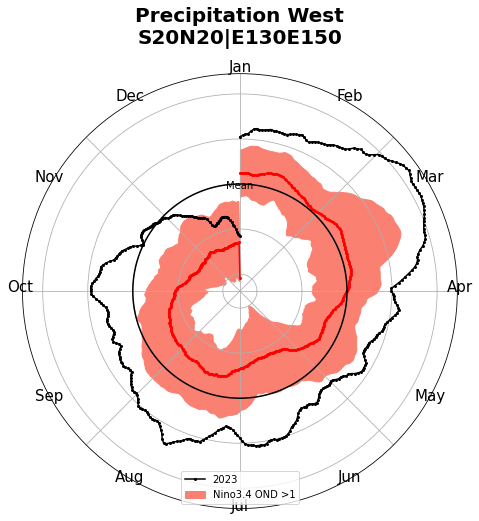

In [7]:
months=["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

full_circle_thetas=np.linspace(0,2*np.pi,1000)
blue_one_radii=[0.0+1]*1000



# Extract years and months
years = np.unique(tp.time.dt.year)

# Plotting
fig = plt.figure(figsize=(8,8))
ax = plt.subplot(111, projection='polar')#visuals
ax.axes.get_yaxis().set_ticklabels([])
ax.axes.get_xaxis().set_ticklabels([])

ax.plot(full_circle_thetas, blue_one_radii, c='k', zorder= 10)
ax.text(np.pi/2, 0.90, "Mean", color="k", ha='center', zorder = 10)



#fig.set_facecolor("#323331")
#ax.set_facecolor('#000100')


#ax.text(0,-0.2,"N3.4 OND>1", color='k', size=15, ha='center', va = 'center')

#add months ring
months_angles= -np.linspace(0,2*np.pi,13)+np.pi/2
for i,month in enumerate(months):
    ax.text(months_angles[i],3.5,month,color="k",fontsize=15,ha="center")



for i, year in enumerate(years):
    temp = tp.where((tp.time.dt.year== year), drop = True).glb_anom.values

    # Calculate the angle for the current month
    angle = -np.linspace(0, 2*np.pi, len(temp))+np.pi/2

    # Calculate radius for temperature
    radius = temp +1
    


add_nino = True
    
#year == 2023:

temp = tp.sel(time = '2023').glb_anom.values
angle = -np.linspace(0,2*np.pi, len(temp))+np.pi/2
radius = temp+1
ax.plot(angle, radius, marker = 'o', markersize = 2, label = '2023', color = 'k')

if add_nino:
    #nino
    nino_tp = tp.sel(time = tp.time.dt.year.isin(ninoOND.where(ninoOND.nino34>1, drop = True).year[:-1]))
    temp_m = nino_tp.groupby('time.dayofyear').mean().glb_anom.values
    temp_10 = nino_tp.glb_anom.groupby('time.dayofyear').quantile(.10)
    temp_90 = nino_tp.glb_anom.groupby('time.dayofyear').quantile(.90)

    angle = -np.linspace(0,2*np.pi, len(temp_m))+np.pi/2
    radius_m = temp_m+1
    ax.plot(angle, radius_m, marker = 'o', markersize = 2, color = 'red')
    ax.fill_between(angle, temp_10+1, temp_90+1, color = 'salmon', label = 'Nino3.4 OND >1')



# Set title and show the plot
ax.set_title("Precipitation West\nS20N20|E130E150", color='k', fontdict={'fontsize': 20}, pad  = 30)
ax.legend(loc = 'lower center')

#fig.savefig('/data/jmex/output/figures/sandrine/spiral_nino.png')
plt.show()



In [45]:
tp.glb_anom.sum()

<xarray.DataArray 'glb_anom' ()>
array(136.82886, dtype=float32)

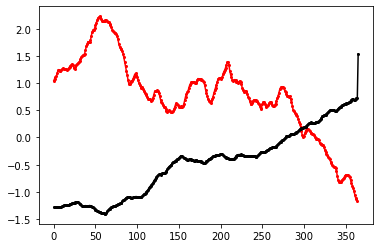

In [51]:
plt.plot(temp, marker = 'o', markersize = 2, color = 'red')
plt.plot(temp_m, marker = 'o', markersize = 2, color = 'k')

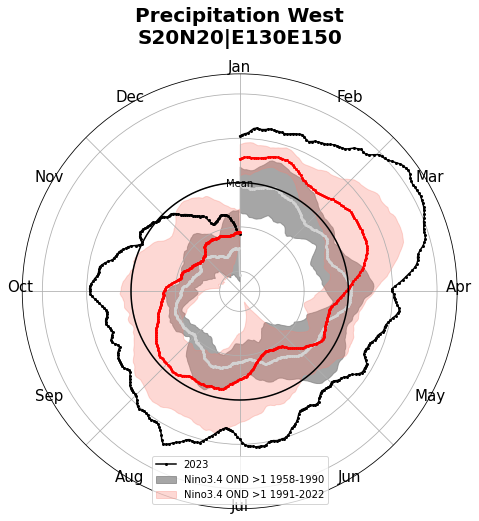

In [71]:
months=["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

full_circle_thetas=np.linspace(0,2*np.pi,1000)
blue_one_radii=[0.0+1]*1000



# Extract years and months
years = np.unique(tp.time.dt.year)

# Plotting
fig = plt.figure(figsize=(8,8))
ax = plt.subplot(111, projection='polar')#visuals
ax.axes.get_yaxis().set_ticklabels([])
ax.axes.get_xaxis().set_ticklabels([])

ax.plot(full_circle_thetas, blue_one_radii, c='k', zorder= 10)
ax.text(np.pi/2, 0.90, "Mean", color="k", ha='center', zorder = 10)



#fig.set_facecolor("#323331")
#ax.set_facecolor('#000100')


#ax.text(0,-0.2,"N3.4 OND>1", color='k', size=15, ha='center', va = 'center')

#add months ring
months_angles= -np.linspace(0,2*np.pi,13)+ np.pi/2
for i,month in enumerate(months):
    ax.text(months_angles[i],3.5,month,color="k",fontsize=15,ha="center")



for i, year in enumerate(years):
    temp = tp.where((tp.time.dt.year== year), drop = True).glb_anom.values

    # Calculate the angle for the current month
    angle = -np.linspace(0, 2*np.pi, len(temp))+np.pi/2

    # Calculate radius for temperature
    radius = temp +1
    
    break
    ax.plot(angle, radius, marker='o', markersize=2, c='lightgrey')
    
    if ninoOND.nino34.sel(year = year)>1:
        # Plot a point at the calculated angle and radius
        ax.plot(angle, radius, marker='o', markersize=2, c='r', zorder = 10)#plt.cm.inferno(ninoOND.nino34.sel(year = year)), zorder = 10)
    
    if ninoOND.nino34.sel(year = year)<-1:
        # Plot a point at the calculated angle and radius
        ax.plot(angle, radius, marker='o', markersize=2, c='b', zorder = 10)#plt.cm.inferno(ninoOND.nino34.sel(year = year)), zorder = 10)
    

add_nino2 = True

    
#year == 2023:

temp = tp.sel(time = '2023').glb_anom.values
angle = -np.linspace(0,2*np.pi, len(temp))+np.pi/2
radius = temp+1
ax.plot(angle, radius, marker = 'o', markersize = 2, label = '2023', color = 'k')


if add_nino2:
    #nino
    nino_tp = tp.sel(time = tp.time.dt.year.isin(ninoOND.where(ninoOND.nino34>1, drop = True).year[:-1]))
    nino_tp1 = nino_tp.sel(time = slice('1958', '1990'))
    nino_tp2 = nino_tp.sel(time = slice('1991', '2023'))
    
    temp_m1 = nino_tp1.groupby('time.dayofyear').mean().glb_anom.values
    temp_m2 = nino_tp2.groupby('time.dayofyear').mean().glb_anom.values
    
    temp_101 = nino_tp1.glb_anom.groupby('time.dayofyear').quantile(.10)
    temp_901 = nino_tp1.glb_anom.groupby('time.dayofyear').quantile(.90)

     
    temp_102 = nino_tp2.glb_anom.groupby('time.dayofyear').quantile(.10)
    temp_902 = nino_tp2.glb_anom.groupby('time.dayofyear').quantile(.90)

    angle = -np.linspace(0,2*np.pi, len(temp_m1))+np.pi/2
    radius_m = temp_m1+1
    ax.plot(angle, radius_m, marker = 'o', markersize = 2, color = 'lightgrey')
    ax.fill_between(angle, temp_101+1, temp_901+1, color = 'grey', label = 'Nino3.4 OND >1 1958-1990', alpha = 0.7)
    
    
    angle = -np.linspace(0,2*np.pi, len(temp_m2))+np.pi/2
    radius_m = temp_m2+1
    ax.plot(angle, radius_m, marker = 'o', markersize = 2, color = 'red')
    ax.fill_between(angle, temp_102+1, temp_902+1, color = 'salmon', label = 'Nino3.4 OND >1 1991-2022', alpha = 0.3)
    



# Set title and show the plot
ax.set_title("Precipitation West\nS20N20|E130E150", color='k', fontdict={'fontsize': 20}, pad  = 30)
ax.legend(loc = 'lower center')

#fig.savefig('/data/jmex/output/figures/sandrine/spiral_nino_periods.png')
plt.show()



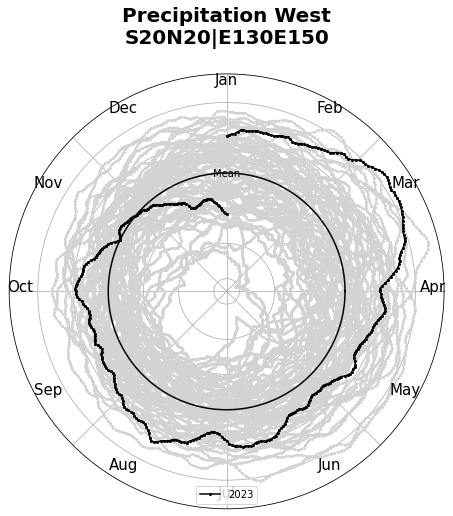

In [8]:
months=["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

full_circle_thetas=np.linspace(0,2*np.pi,1000)
blue_one_radii=[0.0+1]*1000



# Extract years and months
years = np.unique(tp.time.dt.year)

# Plotting
fig = plt.figure(figsize=(8,8))
ax = plt.subplot(111, projection='polar')#visuals
ax.axes.get_yaxis().set_ticklabels([])
ax.axes.get_xaxis().set_ticklabels([])

ax.plot(full_circle_thetas, blue_one_radii, c='k', zorder= 10)
ax.text(np.pi/2, 0.90, "Mean", color="k", ha='center', zorder = 10)



#fig.set_facecolor("#323331")
#ax.set_facecolor('#000100')


#ax.text(0,0,"1958", color='white', size=30, ha='center')

#add months ring
months_angles= -np.linspace(0,2*np.pi,13)+np.pi/2
for i,month in enumerate(months):
    ax.text(months_angles[i],3.5,month,color="k",fontsize=15,ha="center")

    

add_all = True

# Define colors for each year
#colors = plt.cm.plasma(np.linspace(0, 1, len(years)))

for i, year in enumerate(years):
    temp = tp.where((tp.time.dt.year== year), drop = True).glb_anom.values

    # Calculate the angle for the current month
    angle = -np.linspace(0, 2*np.pi, len(temp))+np.pi/2

    # Calculate radius for temperature
    radius = temp +1
    
    if add_all:
        ax.plot(angle, radius, marker='o', markersize=2, c='lightgrey')

    
    
#year == 2023:

temp = tp.sel(time = '2023').glb_anom.values
angle = -np.linspace(0,2*np.pi, len(temp))+np.pi/2
radius = temp+1
ax.plot(angle, radius, marker = 'o', markersize = 2, label = '2023', color = 'k')


#year == 2009:
if False:
    temp = tp.sel(time = '2009').glb_anom.values
    angle = -np.linspace(0,2*np.pi, len(temp))+np.pi/2
    radius = temp+1
    ax.plot(angle, radius, marker = 'o', markersize = 2, label = '2009', color = 'g')



#year == 1972:
if False:
    temp = tp.sel(time = '1972').glb_anom.values
    angle = -np.linspace(0,2*np.pi, len(temp))+np.pi/2
    radius = temp+1
    ax.plot(angle, radius, marker = 'o', markersize = 2, label = '1972', color = 'yellow')

    
    
#year == 1965:
if False:
    temp = tp.sel(time = '1965').glb_anom.values
    angle = -np.linspace(0,2*np.pi, len(temp))+np.pi/2
    radius = temp+1
    ax.plot(angle, radius, marker = 'o', markersize = 2, label = '1965', color = 'yellow')

    
        
#year == 2015:
if False:
    temp = tp.sel(time = '2015').glb_anom.values
    angle = -np.linspace(0,2*np.pi, len(temp))+np.pi/2
    radius = temp+1
    ax.plot(angle, radius, marker = 'o', markersize = 2, label = '2015', color = 'r')

    
#Set title and show the plot
ax.set_title("Precipitation West\nS20N20|E130E150", color='k', fontdict={'fontsize': 20}, pad  = 30)
ax.legend(loc = 'lower center')

#fig.savefig('/data/jmex/output/figures/sandrine/spiral_all.png')


plt.show()



In [ ]:
    
#year == 1997:
if True:
    temp = tp.sel(time = '1997').glb_anom.values
    angle = -np.linspace(0,2*np.pi, len(temp))+np.pi/2
    radius = temp+1
    ax.plot(angle, radius, marker = 'o', markersize = 2, label = '1997', color = 'yellow')


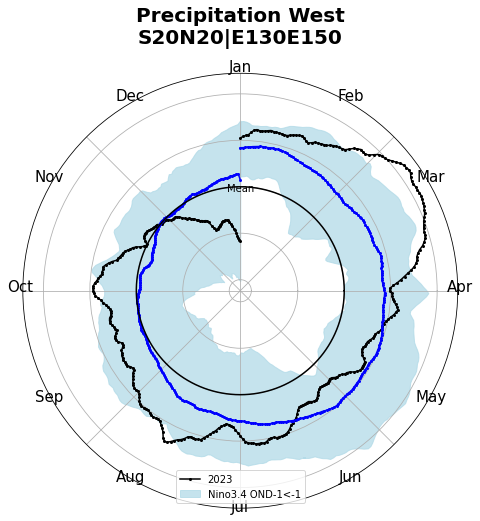

In [69]:
months=["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

full_circle_thetas=np.linspace(0,2*np.pi,1000)
blue_one_radii=[0.0+1]*1000



# Extract years and months
years = np.unique(tp.time.dt.year)

# Plotting
fig = plt.figure(figsize=(8,8))
ax = plt.subplot(111, projection='polar')#visuals
ax.axes.get_yaxis().set_ticklabels([])
ax.axes.get_xaxis().set_ticklabels([])

ax.plot(full_circle_thetas, blue_one_radii, c='k', zorder= 10)
ax.text(np.pi/2, 0.90, "Mean", color="k", ha='center', zorder = 10)



#fig.set_facecolor("#323331")
#ax.set_facecolor('#000100')


#ax.text(0,0,"1958", color='white', size=30, ha='center')

#add months ring
months_angles= -np.linspace(0,2*np.pi,13) + np.pi/2
for i,month in enumerate(months):
    ax.text(months_angles[i],3.5,month,color="k",fontsize=15,ha="center")

    
add_all = False
add_nina = True

# Define colors for each year
#colors = plt.cm.plasma(np.linspace(0, 1, len(years)))

for i, year in enumerate(years):
    temp = tp.where((tp.time.dt.year== year), drop = True).glb_anom.values

    # Calculate the angle for the current month
    angle = -np.linspace(0, 2*np.pi, len(temp))+np.pi/2

    # Calculate radius for temperature
    radius = temp +1
    
    if add_all:
        ax.plot(angle, radius, marker='o', markersize=2, c='lightgrey')

    
    
#year == 2023:

temp = tp.sel(time = '2023').glb_anom.values
angle = -np.linspace(0,2*np.pi, len(temp))+np.pi/2
radius = temp+1
ax.plot(angle, radius, marker = 'o', markersize = 2, label = '2023', color = 'k')


if add_nina:
    #nina
    nina_tp = tp.sel(time = tp.time.dt.year.isin(ninoOND.where(ninoOND.nino34<-1, drop = True).year+1))
    temp_m = nina_tp.groupby('time.dayofyear').mean().glb_anom.values
    temp_10 = nina_tp.glb_anom.groupby('time.dayofyear').quantile(.01)
    temp_90 = nina_tp.glb_anom.groupby('time.dayofyear').quantile(.90)


    angle = -np.linspace(0,2*np.pi, len(temp_m))+np.pi/2
    radius_m = temp_m+1
    ax.plot(angle, radius_m, marker = 'o', markersize = 2, color = 'blue')
    ax.fill_between(angle, temp_10+1, temp_90+1, color = 'lightblue', alpha = 0.7, label = 'Nino3.4 OND-1<-1')

# Set title and show the plot
ax.set_title("Precipitation West\nS20N20|E130E150", color='k', fontdict={'fontsize': 20}, pad  = 30)
ax.legend(loc = 'lower center')

#fig.savefig('/data/jmex/output/figures/sandrine/spiral_nina.png')


plt.show()


<AxesSubplot:ylabel='Count'>

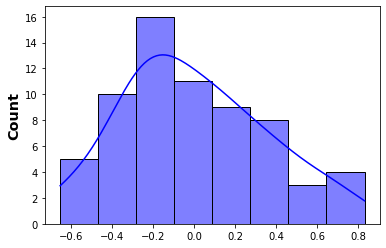

In [8]:
# Plot histogram with KDE using seaborn
sns.histplot(ninoOND.ninowest, kde=True, color='blue', edgecolor='black')


AttributeError: 'Dataset' object has no attribute 'glb_anom'

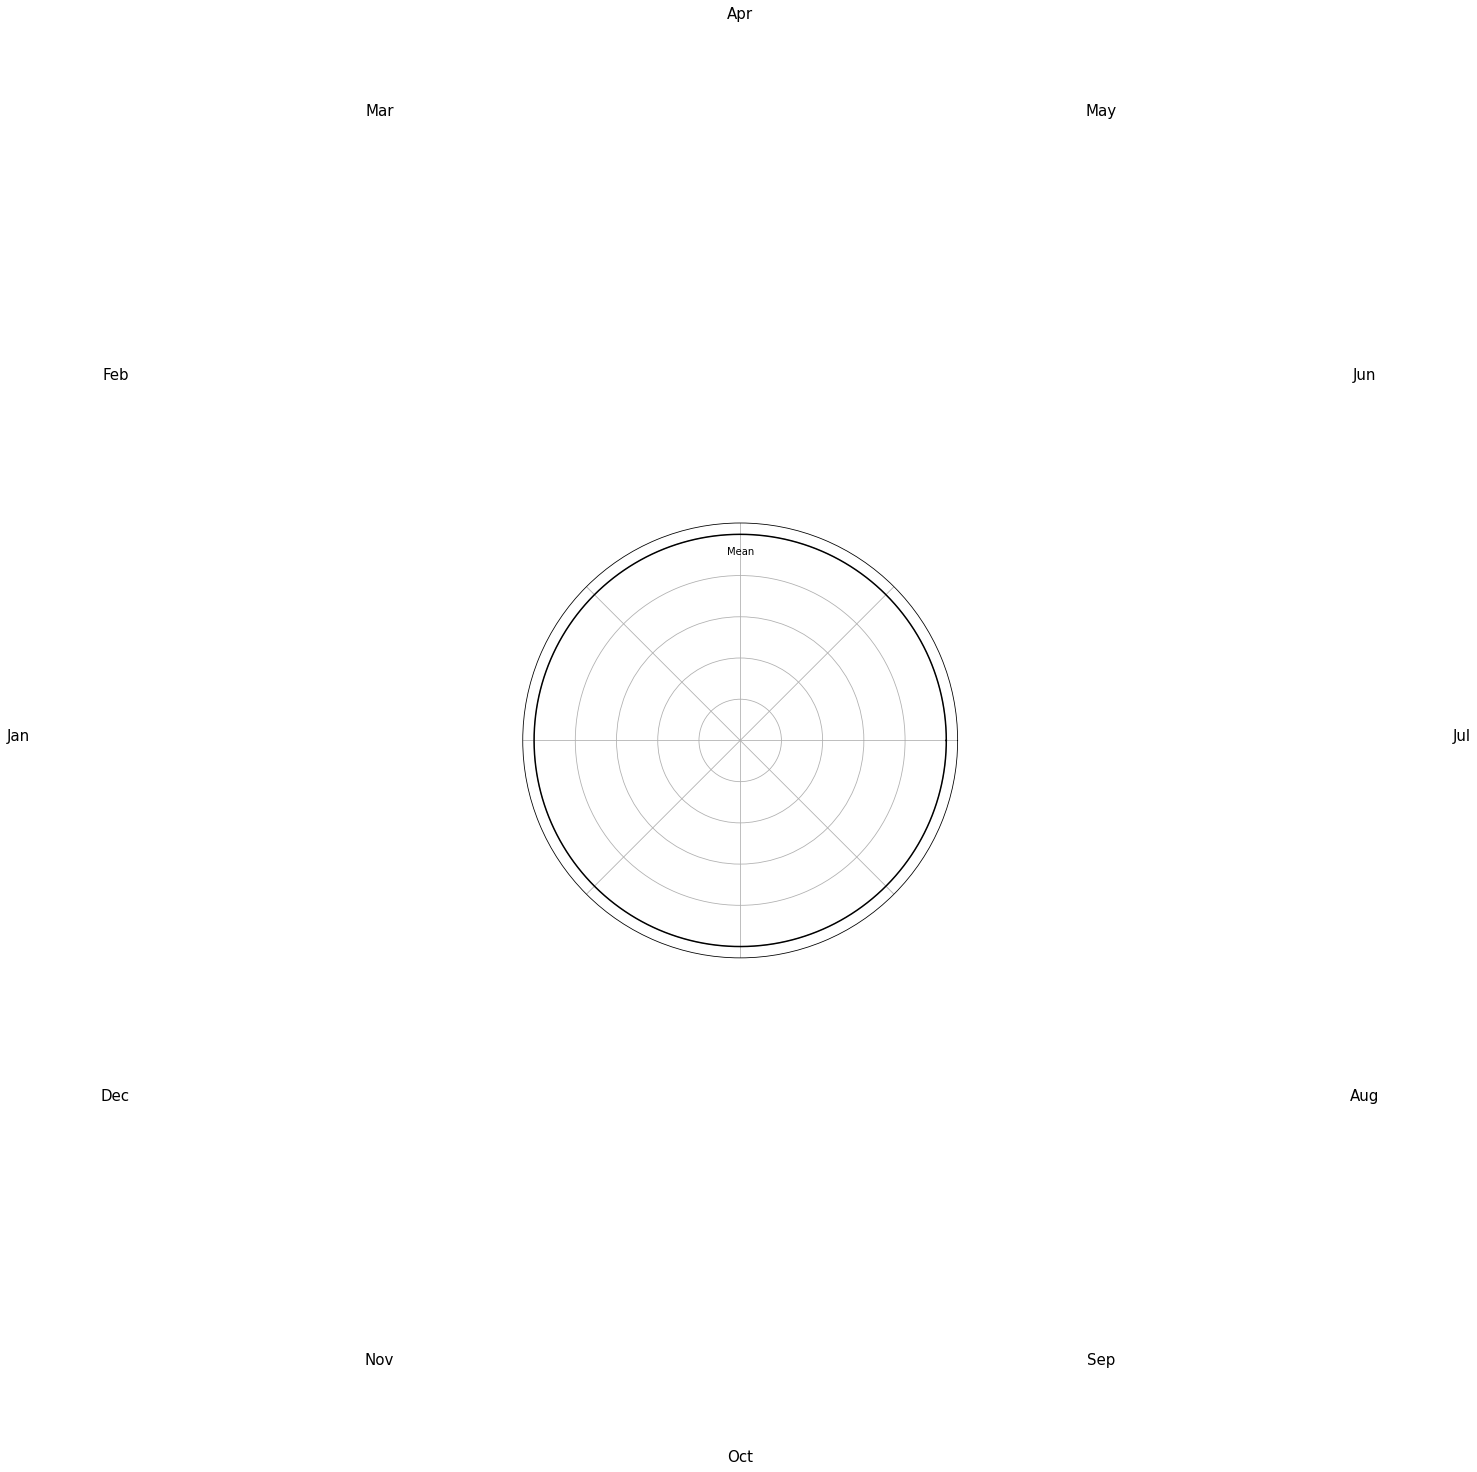

In [19]:
months=["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

full_circle_thetas=np.linspace(0,2*np.pi,1000)
blue_one_radii=[0.0+1]*1000



# Extract years and months
years = np.unique(tp.time.dt.year)

# Plotting
fig = plt.figure(figsize=(8,8))
ax = plt.subplot(111, projection='polar')#visuals
ax.axes.get_yaxis().set_ticklabels([])
ax.axes.get_xaxis().set_ticklabels([])

ax.plot(full_circle_thetas, blue_one_radii, c='k', zorder= 10)
ax.text(np.pi/2, 0.90, "Mean", color="k", ha='center', zorder = 10)



#fig.set_facecolor("#323331")
#ax.set_facecolor('#000100')


#ax.text(0,0,"1958", color='white', size=30, ha='center')

#add months ring
months_angles= -np.linspace(0,2*np.pi,13)+np.pi
for i,month in enumerate(months):
    ax.text(months_angles[i],3.5,month,color="k",fontsize=15,ha="center")

    

add_all = True
add_nino = False
add_nina = False

# Define colors for each year
#colors = plt.cm.plasma(np.linspace(0, 1, len(years)))

for i, year in enumerate(years):
    temp = tp.where((tp.time.dt.year== year), drop = True).glb_anom.values

    # Calculate the angle for the current month
    angle = np.linspace(0, 2*np.pi, len(temp))

    # Calculate radius for temperature
    radius = temp +1
    
    if add_all:
        ax.plot(angle, radius, marker='o', markersize=2, c='lightgrey')

    
    
#year == 2023:

temp = tp.sel(time = '2023').glb_anom.values
angle = np.linspace(0,2*np.pi, len(temp))
radius = temp+1
ax.plot(angle, radius, marker = 'o', markersize = 2, label = '2023', color = 'k')


if add_nino:
    #nino
    nino_tp = tp.sel(time = tp.time.dt.year.isin(nino.where(nino.groupby('time.year').mean().ninowest>0.2, drop = True).year[:-1]))
    temp_m = nino_tp.groupby('time.dayofyear').mean().glb_anom.values
    temp_10 = nino_tp.glb_anom.groupby('time.dayofyear').quantile(.01)
    temp_90 = nino_tp.glb_anom.groupby('time.dayofyear').quantile(.99)

    angle = np.linspace(0,2*np.pi, len(temp_m))
    radius_m = temp_m+1
    ax.plot(angle, radius_m, marker = 'o', markersize = 2, color = 'red')
    ax.fill_between(angle, temp_10+1, temp_90+1, color = 'salmon')



if add_nina:
    #nina
    nina_tp = tp.sel(time = tp.time.dt.year.isin(ninoOND.where(ninoOND.ninowest<-0.4, drop = True).year+1))
    temp_m = nina_tp.groupby('time.dayofyear').mean().glb_anom.values
    temp_10 = nina_tp.glb_anom.groupby('time.dayofyear').quantile(.01)
    temp_90 = nina_tp.glb_anom.groupby('time.dayofyear').quantile(.99)


    angle = np.linspace(0,2*np.pi, len(temp_m))
    radius_m = temp_m+1
    ax.plot(angle, radius_m, marker = 'o', markersize = 2, color = 'red')
    ax.fill_between(angle, temp_10+1, temp_90+1, color = 'salmon', alpha = 0.7, label = 'NinoWest OND-1 <-0.4')
 
# Set title and show the plot
ax.set_title("Precipitation West", color='k', fontdict={'fontsize': 20}, pad  = 20)
ax.legend()

#fig.savefig('/data/jmex/output/figures/sandrine/spiral_west-.png')


plt.show()

In [66]:
(nino.groupby('time.year').mean()).where( nino.groupby('time.year').mean()>0.2, drop = True).year

<xarray.DataArray 'year' (year: 52)>
array([1958, 1959, 1965, 1966, 1969, 1971, 1972, 1974, 1975, 1976, 1977, 1979,
       1980, 1982, 1983, 1984, 1987, 1989, 1990, 1991, 1992, 1993, 1994, 1995,
       1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007,
       2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019,
       2020, 2021, 2022, 2023])
Coordinates:
  * year     (year) int64 1958 1959 1965 1966 1969 ... 2019 2020 2021 2022 2023

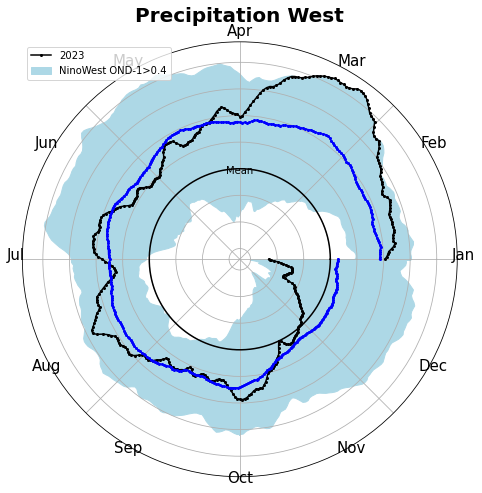

In [12]:
months=["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

full_circle_thetas=np.linspace(0,2*np.pi,1000)
blue_one_radii=[0.0+1]*1000



# Extract years and months
years = np.unique(tp.time.dt.year)

# Plotting
fig = plt.figure(figsize=(8,8))
ax = plt.subplot(111, projection='polar')#visuals
ax.axes.get_yaxis().set_ticklabels([])
ax.axes.get_xaxis().set_ticklabels([])

ax.plot(full_circle_thetas, blue_one_radii, c='k', zorder= 10)
ax.text(np.pi/2, 0.90, "Mean", color="k", ha='center', zorder = 10)



#fig.set_facecolor("#323331")
#ax.set_facecolor('#000100')


#ax.text(0,0,"1958", color='white', size=30, ha='center')

#add months ring
months_angles= np.linspace(0,2*np.pi,13)
for i,month in enumerate(months):
    ax.text(months_angles[i],3.5,month,color="k",fontsize=15,ha="center")

    

add_all = False
add_nino = True
add_nina = False

# Define colors for each year
#colors = plt.cm.plasma(np.linspace(0, 1, len(years)))

for i, year in enumerate(years):
    temp = tp.where((tp.time.dt.year== year), drop = True).glb_anom.values

    # Calculate the angle for the current month
    angle = np.linspace(0, 2*np.pi, len(temp))

    # Calculate radius for temperature
    radius = temp +1
    
    if add_all:
        ax.plot(angle, radius, marker='o', markersize=2, c='lightgrey')

    
    
#year == 2023:

temp = tp.sel(time = '2023').glb_anom.values
angle = np.linspace(0,2*np.pi, len(temp))
radius = temp+1
ax.plot(angle, radius, marker = 'o', markersize = 2, label = '2023', color = 'k')


if add_nino:
    #nino
    nino_tp = tp.sel(time = tp.time.dt.year.isin(ninoOND.where(ninoOND.ninowest>0.4, drop = True).year[:-1]+1))
    temp_m = nino_tp.groupby('time.dayofyear').mean().glb_anom.values
    temp_10 = nino_tp.glb_anom.groupby('time.dayofyear').quantile(.01)
    temp_90 = nino_tp.glb_anom.groupby('time.dayofyear').quantile(.99)

    angle = np.linspace(0,2*np.pi, len(temp_m))
    radius_m = temp_m+1
    ax.plot(angle, radius_m, marker = 'o', markersize = 2, color = 'blue')
    ax.fill_between(angle, temp_10+1, temp_90+1, color = 'lightblue', label = 'NinoWest OND-1>0.4')



if add_nina:
    #nina
    nina_tp = tp.sel(time = tp.time.dt.year.isin(ninoOND.where(ninoJAS.ninowest<-0.4, drop = True).year))
    temp_m = nina_tp.groupby('time.dayofyear').mean().glb_anom.values
    temp_10 = nina_tp.glb_anom.groupby('time.dayofyear').quantile(.01)
    temp_90 = nina_tp.glb_anom.groupby('time.dayofyear').quantile(.99)


    angle = np.linspace(0,2*np.pi, len(temp_m))
    radius_m = temp_m+1
    ax.plot(angle, radius_m, marker = 'o', markersize = 2, color = 'blue')
    ax.fill_between(angle, temp_10+1, temp_90+1, color = 'lightblue', alpha = 0.7, label = 'NinoWest OND-1>0.4')
 
#Set title and show the plot
ax.set_title("Precipitation West", color='k', fontdict={'fontsize': 20}, pad  = 20)
ax.legend()

fig.savefig('/data/jmex/output/figures/sandrine/spiral_west+.png')


plt.show()

AttributeError: 'Dataset' object has no attribute 'glb_anom'

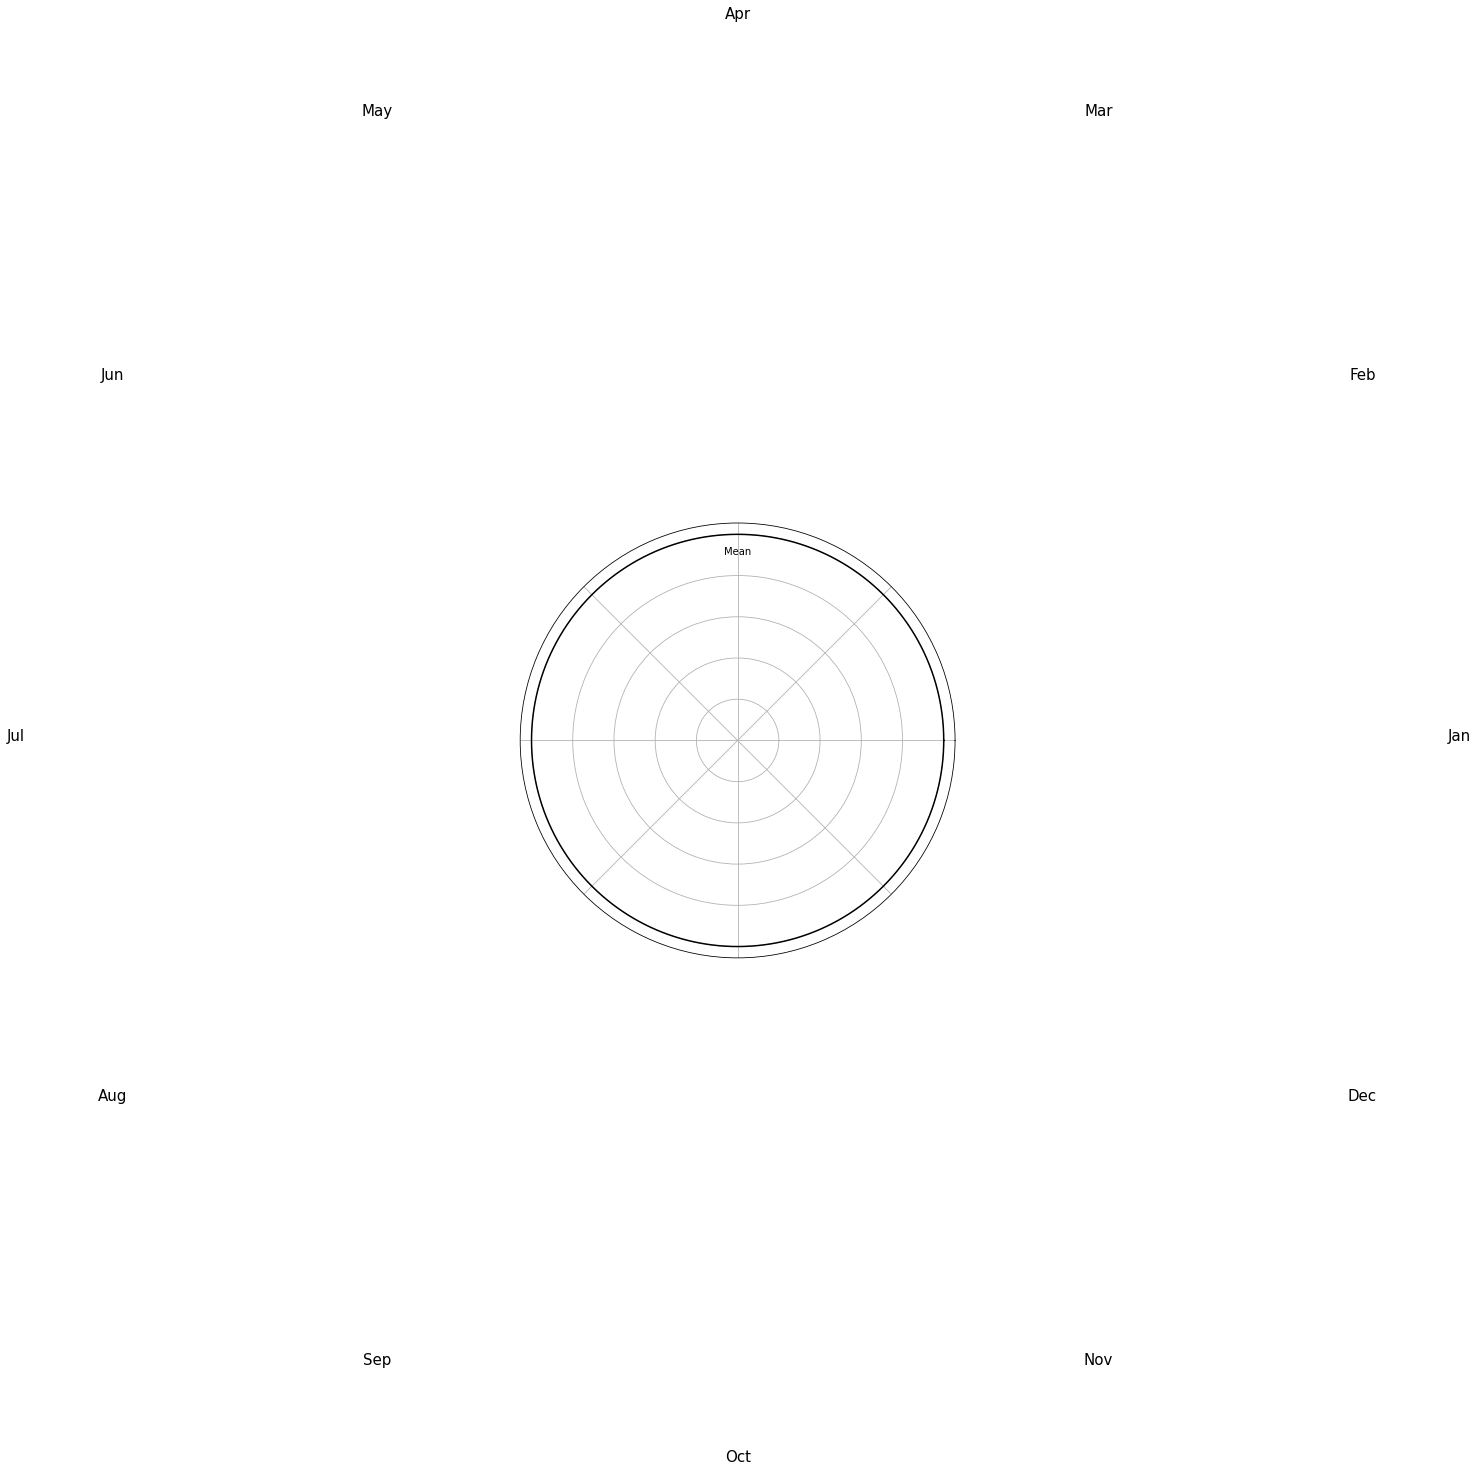

In [20]:
months=["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

full_circle_thetas=np.linspace(0,2*np.pi,1000)
blue_one_radii=[0.0+1]*1000



# Extract years and months
years = np.unique(tp.time.dt.year)

# Plotting
fig = plt.figure(figsize=(8,8))
ax = plt.subplot(111, projection='polar')#visuals
ax.axes.get_yaxis().set_ticklabels([])
ax.axes.get_xaxis().set_ticklabels([])

ax.plot(full_circle_thetas, blue_one_radii, c='k', zorder= 10)
ax.text(np.pi/2, 0.90, "Mean", color="k", ha='center', zorder = 10)



#fig.set_facecolor("#323331")
#ax.set_facecolor('#000100')


#ax.text(0,0,"1958", color='white', size=30, ha='center')

#add months ring
months_angles= np.linspace(0,2*np.pi,13)
for i,month in enumerate(months):
    ax.text(months_angles[i],3.5,month,color="k",fontsize=15,ha="center")

    

add_all = False
add_nino = True
add_nina = False

# Define colors for each year
#colors = plt.cm.plasma(np.linspace(0, 1, len(years)))

for i, year in enumerate(years):
    temp = tp.where((tp.time.dt.year== year), drop = True).glb_anom.values

    # Calculate the angle for the current month
    angle = np.linspace(0, 2*np.pi, len(temp))

    # Calculate radius for temperature
    radius = temp +1
    
    if add_all:
        ax.plot(angle, radius, marker='o', markersize=2, c='lightgrey')
        
#year == 2023:

temp = tp.sel(time = '2023').glb_anom.values
angle = np.linspace(0,2*np.pi, len(temp))
radius = temp+1
ax.plot(angle, radius, marker = 'o', markersize = 2, label = '2023', color = 'k')


#Set title and show the plot
ax.set_title("Precipitation West", color='k', fontdict={'fontsize': 20}, pad  = 20)
ax.legend()



In [21]:
tp

<xarray.Dataset>
Dimensions:  (time: 24106, lon: 40, lat: 80)
Coordinates:
  * time     (time) datetime64[ns] 1958-01-01 1958-01-02 ... 2023-12-31
  * lon      (lon) float32 130.1 130.6 131.1 131.6 ... 148.1 148.6 149.1 149.6
  * lat      (lat) float32 19.88 19.38 18.88 18.38 ... -18.62 -19.12 -19.62
Data variables:
    tp       (time, lat, lon) float32 1.923 1.767 1.68 ... 3.925 2.705 2.133
Attributes: (12/21)
    title:                      subset of "ERA5 reanalysis, https://www.ecmwf...
    Conventions:                CF-1.0
    source_field:               https://climexp.knmi.nl/select.cgi?field=era5...
    cdi:                        Climate Data Interface version 2.3.0 (https:/...
    institution:                KNMI Climate Explorer and European Centre for...
    frequency:                  day
    ...                         ...
    geospatial_lon_resolution:  0.5
    time_coverage_start:        1950-01-01
    time_coverage_end:          2024-02-29
    climexp_url:                https://climexp.knmi.nl/select.cgi?era5_tp_daily
    scripturl01:                http://climexp.knmi.nl/get_index.cgi?email=so...
    history:                     2024-03-08 12:42:37 ./bin/get_index ERA5/era...